<a href="https://colab.research.google.com/github/clara-eng/codveda-tasks/blob/main/Customer_Churn_Prediction_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Scikit-learn: evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

print('All libraries loaded successfully.')
print(f'   pandas  {pd.__version__}  |  numpy {np.__version__}  |  sklearn installed')

All libraries loaded successfully.
   pandas  2.2.2  |  numpy 2.0.2  |  sklearn installed


In [ ]:
#  Mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print(' Google Drive mounted.')
except ImportError:
    print(' Not running in Colab — skipping Drive mount.')


DATASET_PATH = '/content/drive/MyDrive/SKS task/Telco_Customer_Churn_Dataset  (1).csv'


print(f' Dataset path set to: {DATASET_PATH}')

Mounted at /content/drive
 Google Drive mounted.
 Dataset path set to: /content/drive/MyDrive/SKS task/Telco_Customer_Churn_Dataset  (1).csv


In [ ]:
#Load dataset
df = pd.read_csv(DATASET_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n── First 5 rows ──')
df.head()

Dataset shape: 7,043 rows × 21 columns

── First 5 rows ──


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Schema & data types
print('── DataFrame Info ──')
df.info()

── DataFrame Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [ ]:
#Statistical summary of numerical columns
print('── Numerical Summary ──')
df.describe().T.style.background_gradient(cmap='Blues')

── Numerical Summary ──


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000000,0.162147,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
tenure,7043.000000,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
MonthlyCharges,7043.000000,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000


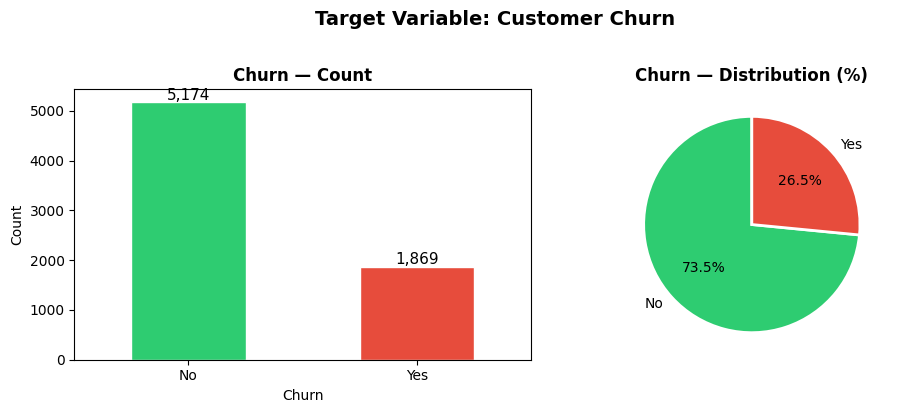

Churn
No     73.463013
Yes    26.536987


In [ ]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count bar
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Churn — Count', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_pct, labels=churn_pct.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn — Distribution (%)', fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(churn_pct.to_string())

In [ ]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print(' No missing values detected in any column.')
else:
    print(' Columns with missing values:')
    display(missing_df)
    # Fill numeric columns with median, categorical with mode
    for col in missing_df.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f'   Filled "{col}" (numeric) with median.')
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'   Filled "{col}" (categorical) with mode.')

 No missing values detected in any column.


In [ ]:
#Fix known type issues in Telco dataset
# 'TotalCharges' is often stored as a string — convert to float
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    print(" 'TotalCharges' converted to numeric.")

# Drop unique identifier column (not predictive)
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)
    print(" Dropped 'customerID' (non-predictive identifier).")

print(f'\nDataset shape after cleaning: {df.shape}')

 'TotalCharges' converted to numeric.

Dataset shape after cleaning: (7043, 20)


/tmp/ipykernel_1078/1369008605.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
# Encode TARGET variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(' Target encoded:  Yes → 1  |  No → 0')
print(df['Churn'].value_counts())

 Target encoded:  Yes → 1  |  No → 0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Encode FEATURE variables

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns found ({len(categorical_cols)}): {categorical_cols}')

binary_cols     = [c for c in categorical_cols if df[c].nunique() == 2]
multiclass_cols = [c for c in categorical_cols if df[c].nunique() > 2]

print(f'\n  Binary   (Label Encoding)  → {binary_cols}')
print(f'  Multi    (One-Hot Encoding) → {multiclass_cols}')

# Label-encode binary columns
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot-encode multi-class columns
df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)

# Convert boolean dummies to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'\n Encoding complete. New dataset shape: {df.shape}')
df.head(3)

Categorical columns found (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

  Binary   (Label Encoding)  → ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
  Multi    (One-Hot Encoding) → ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

 Encoding complete. New dataset shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Separate features (X) and target (y
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')

#  Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'\nTraining set   : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set       : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nChurn rate — Train : {y_train.mean()*100:.1f}%')
print(f'Churn rate — Test  : {y_test.mean()*100:.1f}%')

Feature matrix X: (7043, 30)
Target vector  y: (7043,)

Training set   : 5,634 samples (80%)
Test set       : 1,409 samples (20%)

Churn rate — Train : 26.5%
Churn rate — Test  : 26.5%


In [ ]:
# ── Feature Scaling ────────────────────────────────────────────────────────────

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(' StandardScaler applied (fit on training set only — no data leakage).')

 StandardScaler applied (fit on training set only — no data leakage).


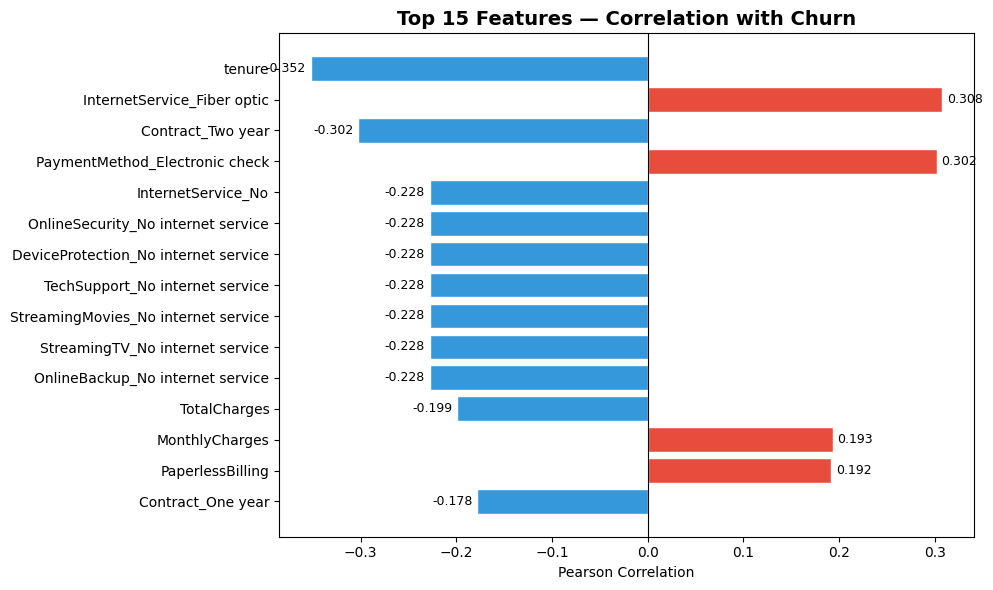

In [ ]:
# Correlation with target
corr_with_target = df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

top_n = 15
top_corr = corr_with_target.head(top_n)

colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} Features — Correlation with Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, top_corr.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

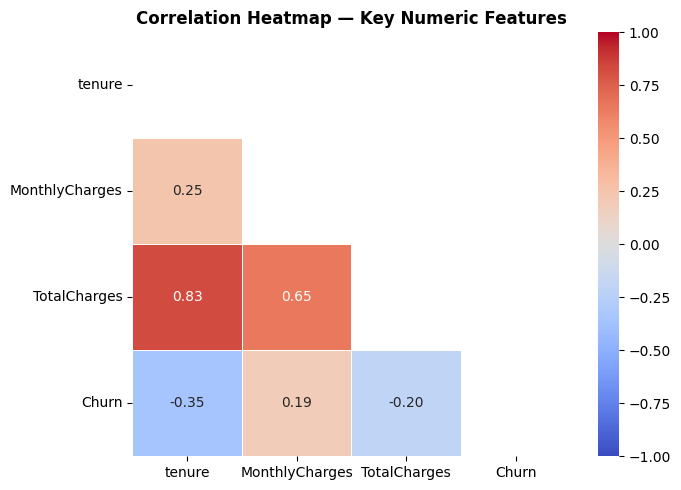

In [ ]:
#Correlation heatmap
num_cols  = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
num_cols  = [c for c in num_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Key Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

# MODEL 1 — Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)
print(' Logistic Regression trained.')


# MODEL 2 — Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print(' Random Forest trained.')

 Logistic Regression trained.
 Random Forest trained.


In [ ]:
def evaluate_model(name, model, X_test_input, y_test):

    y_pred  = model.predict(X_test_input)
    y_proba = model.predict_proba(X_test_input)[:, 1]

    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
    }

    print(f'\n{'═'*55}')
    print(f'  {name}')
    print(f'{'═'*55}')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:<12}: {v:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["No Churn", "Churn"])}')

    return metrics, y_pred, y_proba

In [ ]:
#  Evaluate Logistic Regression
lr_metrics, lr_pred, lr_proba = evaluate_model(
    'Logistic Regression', lr_model, X_test_scaled, y_test
)


═══════════════════════════════════════════════════════
  Logistic Regression
═══════════════════════════════════════════════════════
  Accuracy    : 0.7388
  Precision   : 0.5052
  Recall      : 0.7807
  F1-Score    : 0.6134
  ROC-AUC     : 0.8412

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
# ── Evaluate Random Forest ─────────────────────────────────────────────────────
rf_metrics, rf_pred, rf_proba = evaluate_model(
    'Random Forest', rf_model, X_test, y_test
)


═══════════════════════════════════════════════════════
  Random Forest
═══════════════════════════════════════════════════════
  Accuracy    : 0.7644
  Precision   : 0.5396
  Recall      : 0.7647
  F1-Score    : 0.6327
  ROC-AUC     : 0.8431

              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.78      1409



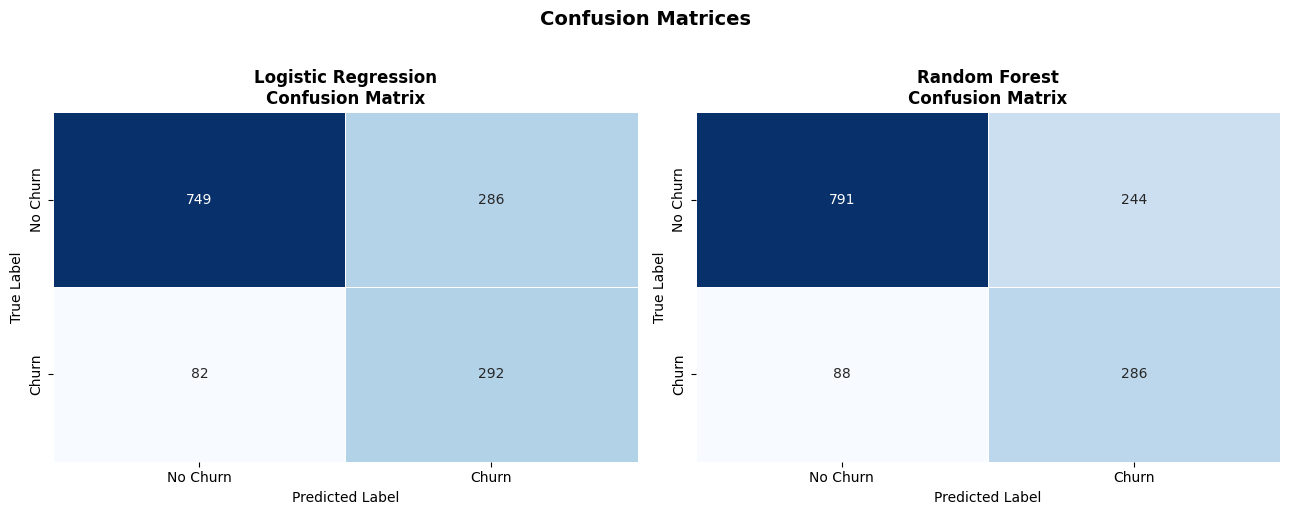

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

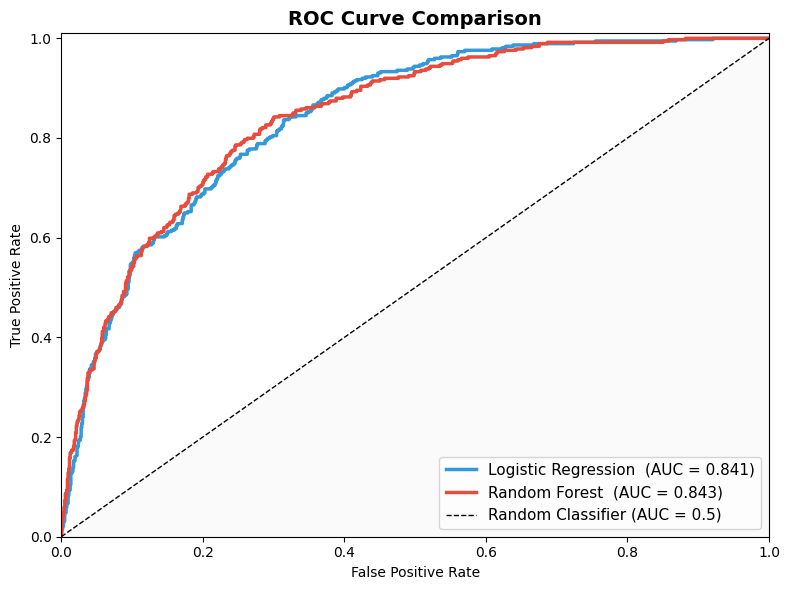

In [ ]:
#  ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Logistic Regression', lr_proba, '#3498db'),
    ('Random Forest',       rf_proba, '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()


── Model Comparison Table ──


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7388,0.5052,0.7807,0.6134,0.8412
Random Forest,0.7644,0.5396,0.7647,0.6327,0.8431


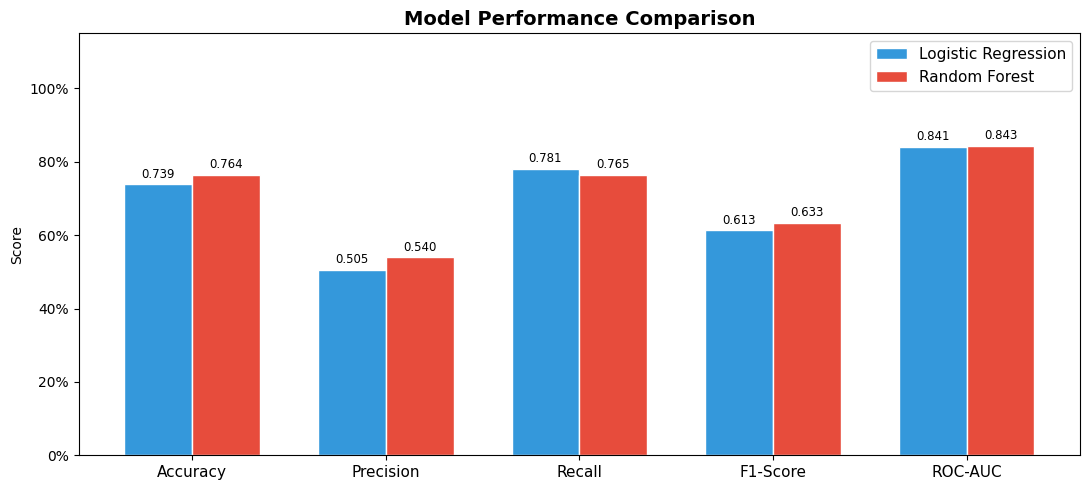

In [ ]:
#  metric comparison
results_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print('\n── Model Comparison Table ──')
display(results_df.style.highlight_max(color='#d5f5e3', axis=0)
                        .format('{:.4f}'))

# Bar chart comparison
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, results_df.loc['Logistic Regression', metric_cols], width,
               label='Logistic Regression', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, results_df.loc['Random Forest', metric_cols], width,
               label='Random Forest', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1078/305043275.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature',


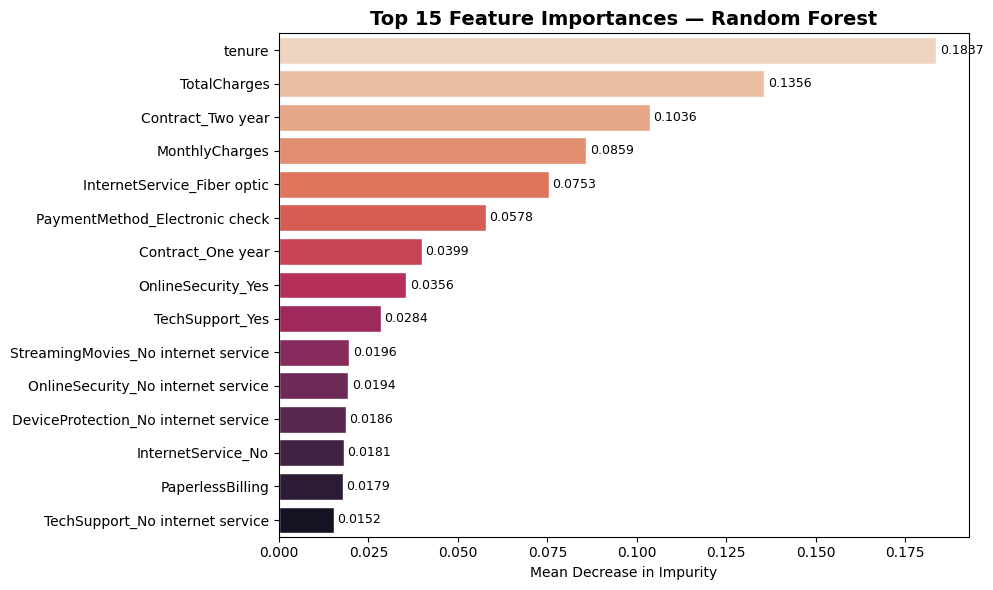

In [ ]:
# ── Feature Importance (Random Forest) ────────────────────────────────────────
importances = rf_model.feature_importances_
feat_names  = X.columns

feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('rocket_r', len(feat_imp_df))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette=palette, ax=ax, edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('')
for bar, val in zip(ax.patches, feat_imp_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

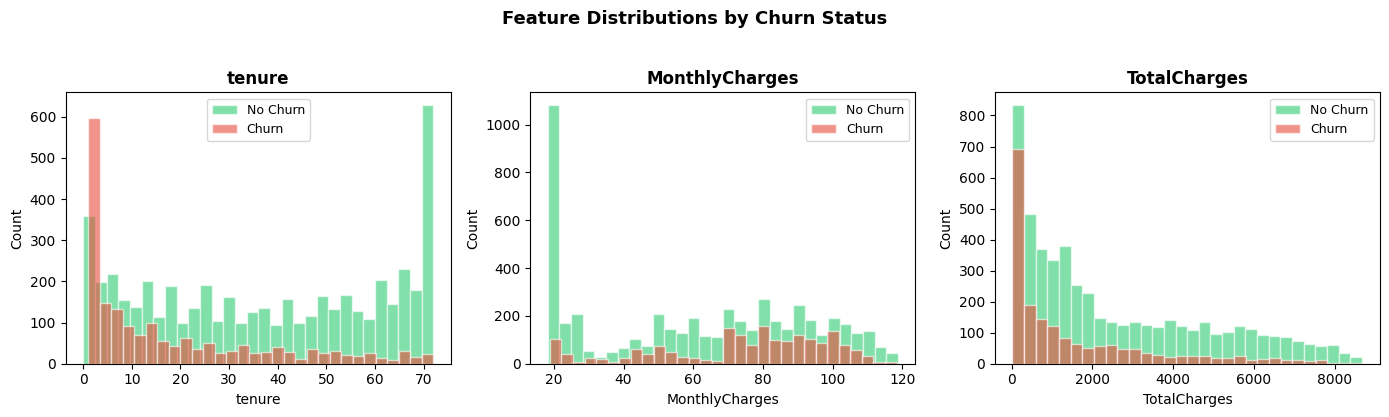

In [ ]:
# Distribution of key numeric features by Churn status
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
numeric_features = [c for c in numeric_features if c in df.columns]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(14, 4))

for ax, feat in zip(axes, numeric_features):
    churned     = df[df['Churn'] == 1][feat]
    not_churned = df[df['Churn'] == 0][feat]
    ax.hist(not_churned, bins=30, alpha=0.6, color='#2ecc71', label='No Churn', edgecolor='white')
    ax.hist(churned,     bins=30, alpha=0.6, color='#e74c3c', label='Churn',    edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Churn Status', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()